# **0. Importar librerias**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
from pathlib import Path
import seaborn as sns
from scipy import stats

# **1. CARGA Y EXPLORACIÓN INICIAL**

In [2]:
main_folder = Path.cwd().parent

data_folder = os.path.join(main_folder, 'data')


csv_files = [f for f in os.listdir(data_folder) if f.endswith('.csv')]
df, df_ip = [pd.read_csv(os.path.join(data_folder, file)) for file in csv_files[:2]]


In [3]:
df.head()

,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class
0,22058,2015-02-24 22:55:49,2015-04-18 02:47:11,34,QVPSPJUOCKZAR,SEO,Chrome,M,39,7.327584e+08,0
1,333320,2015-06-07 20:39:50,2015-06-08 01:38:54,16,EOGFQPIZPYXFZ,Ads,Chrome,F,53,3.503114e+08,0
2,1359,2015-01-01 18:52:44,2015-01-01 18:52:45,15,YSSKYOSJHPPLJ,SEO,Opera,M,53,2.621474e+09,1
3,150084,2015-04-28 21:13:25,2015-05-04 13:54:50,44,ATGTXKYKUDUQN,SEO,Safari,M,41,3.840542e+09,0
4,221365,2015-07-21 07:09:52,2015-09-09 18:40:53,39,NAUITBZFJKHWW,Ads,Safari,M,45,4.155831e+08,0


In [4]:
df_ip.head()

,lower_bound_ip_address,upper_bound_ip_address,country
0,16777216.0,16777471,Australia
1,16777472.0,16777727,China
2,16777728.0,16778239,China
3,16778240.0,16779263,Australia
4,16779264.0,16781311,China


## 1.1 Revisión de columnas y tipo de datos

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 151112 entries, 0 to 151111
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   user_id         151112 non-null  int64  
 1   signup_time     151112 non-null  str    
 2   purchase_time   151112 non-null  str    
 3   purchase_value  151112 non-null  int64  
 4   device_id       151112 non-null  str    
 5   source          151112 non-null  str    
 6   browser         151112 non-null  str    
 7   sex             151112 non-null  str    
 8   age             151112 non-null  int64  
 9   ip_address      151112 non-null  float64
 10  class           151112 non-null  int64  
dtypes: float64(1), int64(4), str(6)
memory usage: 12.7 MB


### 💾 **Observaciones**


Existe un total de **11 columnas** y **151112 registros**.
    - 10 son variables independientes
    - 1 variable dependiente (`class`)

Existen 2 columnas que parecen estar relacionadas con fechas pero están como str: `signup_time`, `purchase_time`.

Hay 5 columnas **numéricas** (`user_id`, `purchase_value`, `user_id`, `age`,`ip_address` y `class`), las 6 restantes son **str**.


No existen datos nulos aparentes.





In [6]:
df_ip.info()

<class 'pandas.DataFrame'>
RangeIndex: 138846 entries, 0 to 138845
Data columns (total 3 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   lower_bound_ip_address  138846 non-null  float64
 1   upper_bound_ip_address  138846 non-null  int64  
 2   country                 138846 non-null  str    
dtypes: float64(1), int64(1), str(1)
memory usage: 3.2 MB


### 💾 **Observaciones**


Existe un total de 3 columnas y 138846.

- 2 son numéricas relacionadas con limites de ip
- 1 de estas es str relacionada con el país de donde se efectuo la compra.



📢 **Conclusión**

Según lo señalado se debe revisar las columnas para ver si es necesario transformar alguna columna. En cuanto a las features relacionadas con tiempo deben ser cambiadas a su tipo correcto.

Revisar si es que en realidad no hay nulos como datos mal inputados, categorias faltantes u otros errores también debe estar presente en el análisis.

**Columnas a corregir**
- signup_time y purchase_time son object --> convertir a datetime
- source, browser, sex son object --> convertir a category (reducir memoria)


## 1.2 Revisión numérica somera

In [7]:
# No ver notación cientifica
pd.set_option('display.float_format', '{:.2f}'.format)

df.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
user_id,151112.00,200171.04,115369.29,2.00,100642.50,199958.00,300054.00,400000.00
purchase_value,151112.00,36.94,18.32,9.00,22.00,35.00,49.00,154.00
age,151112.00,33.14,8.62,18.00,27.00,33.00,39.00,76.00
ip_address,151112.00,2152145330.96,1248497030.10,52093.50,1085933882.53,2154770162.41,3243257679.72,4294850499.68
class,151112.00,0.09,0.29,0.00,0.00,0.00,0.00,1.00


In [8]:
df_ip.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
lower_bound_ip_address,138846.00,2724531562.52,897521519.71,16777216.00,1919930368.00,3230887296.00,3350465280.00,3758096128.00
upper_bound_ip_address,138846.00,2724557062.22,897497915.46,16777471.00,1920008191.00,3230887551.00,3350465919.00,3758096383.00


### 💾 **Observaciones**

`purchase_value`: 
- **promedio**: 36.94 $
- **std**: 18.32 $
- **min**: 9 $
- **max**: 400000.00 $

`age`:

- **promedio**: 33 años
- **std**: 8.62 años
- **min**: 18 años
- **max**: 76 años



`lower_bound_ip_address`:

- **min**: 16777216
- **max**: 3758096128


`upper_bound_ip_address`:

- **min**: 16777471
- **max**: 3758096383

📢 **Conclusión**

El 75 % de los datos esta por debajo de los 49 $ de `purchase_value`. Considerando esto y el valor del maximo es interesante ver cuantos datos están fuera del 75 % y que tan altos son.

  - El std es bastante alto lo que debe ser principalmente por los valores ya nombrados.

La edad promedio de los clientes es de  33 años.
  - La edad mínima es 18 en sintonia con el negocio y la máxima de 76.
  - El std es alto pero no desmezutado como el de la columna anterior


En cuanto IP, podremos ver algo mas relacionandolo con el país.


`df` y `df_ip` se relacionan entre las ip. Con el ip de `df` hay que encontrar dentro de que rango cae y se le puede asignar un país a esa ip.

##  1.4. Unir los dataframes

In [9]:
df_ordenado = df.sort_values('ip_address')
df_ip_ordenado = df_ip.sort_values('lower_bound_ip_address')

df_merged = pd.merge_asof(
    df_ordenado,
    df_ip_ordenado,
    left_on='ip_address',
    right_on='lower_bound_ip_address',
    direction='backward'
)

In [10]:
df_merged.head()

,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class,lower_bound_ip_address,upper_bound_ip_address,country
0,62421,2015-02-16 00:17:05,2015-03-08 10:00:39,46,ZCLZTAJPCRAQX,Direct,Safari,M,36,52093.50,0,NaN,NaN,NaN
1,173212,2015-03-08 04:03:22,2015-03-20 17:23:45,33,YFGYOALADBHLT,Ads,IE,F,30,93447.14,0,NaN,NaN,NaN
2,242286,2015-05-17 16:45:54,2015-05-26 08:54:34,33,QZNVQTUITFTHH,Direct,FireFox,F,32,105818.50,0,NaN,NaN,NaN
3,370003,2015-03-03 19:58:39,2015-05-28 21:09:13,33,PIBUQMBIELMMG,Ads,IE,M,40,117566.66,0,NaN,NaN,NaN
4,119824,2015-03-20 00:31:27,2015-04-05 07:31:46,55,WFIIFCPIOGMHT,Ads,Safari,M,38,131423.79,0,NaN,NaN,NaN


**Detalle**

Uso merge_assoft porque me permite hacer un merge utilizando rangos.
La idea es ordenar ambos dataset por la columna donde quiera comparar los rangos.

Utilizo `ip_address` en la tabla izquierda y `lower_bound_ip_address` en la derecha
para buscar el valor más cercano o igual hacia atrás de cada IP.

Aun así, esto dejará casos donde `ip_address` > `upper_bound_ip_address`.
En esos casos el país se marca como 'Unknown' ya que la IP no pertenece a ese rango.


##  1.5. Duplicados o nulos?

In [11]:
df_merged.isnull().sum()

user_id                     0
signup_time                 0
purchase_time               0
purchase_value              0
device_id                   0
source                      0
browser                     0
sex                         0
age                         0
ip_address                  0
class                       0
lower_bound_ip_address    634
upper_bound_ip_address    634
country                   634
dtype: int64

In [12]:
df_merged.duplicated().sum()

np.int64(0)

📢 Existen 634 valores nulos en el dataframe después de aplicar el merge. No existen duplicados

# **2. EDA**

## **2.1. Variables Numéricas**

In [13]:

tipo_de_datos = set([df_merged[col].dtype for col in df_merged.columns])

print(f'Los tipos de datos presentes en el dataframe son :{tipo_de_datos}')

Los tipos de datos presentes en el dataframe son :{dtype('float64'), <StringDtype(storage='python', na_value=nan)>, dtype('int64')}


In [14]:
numeric_df = df_merged.select_dtypes(include=['int', 'float'])
numeric_df

,user_id,purchase_value,age,ip_address,class,lower_bound_ip_address,upper_bound_ip_address
0,62421,46,36,52093.50,0,NaN,NaN
1,173212,33,30,93447.14,0,NaN,NaN
2,242286,33,32,105818.50,0,NaN,NaN
3,370003,33,40,117566.66,0,NaN,NaN
4,119824,55,38,131423.79,0,NaN,NaN
...,...,...,...,...,...,...,...
151107,361167,39,36,4294673680.77,0,3758096128.00,3758096383.00
151108,62422,62,22,4294714854.85,0,3758096128.00,3758096383.00
151109,260255,17,19,4294719533.35,0,3758096128.00,3758096383.00
151110,172984,9,35,4294822241.88,0,3758096128.00,3758096383.00


## 2.1.1 Target (Variable independiente)

In [15]:
numeric_df['class'].value_counts(normalize=True).rename(index={0: 'Legítimo (0)', 1: 'Fraudulento (1)'})*100

class
Legítimo (0)      90.64
Fraudulento (1)    9.36
Name: proportion, dtype: float64

C:\Users\remoto\AppData\Local\Temp\ipykernel_23568\2676706119.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(["Legítima", "Fraudulenta"])


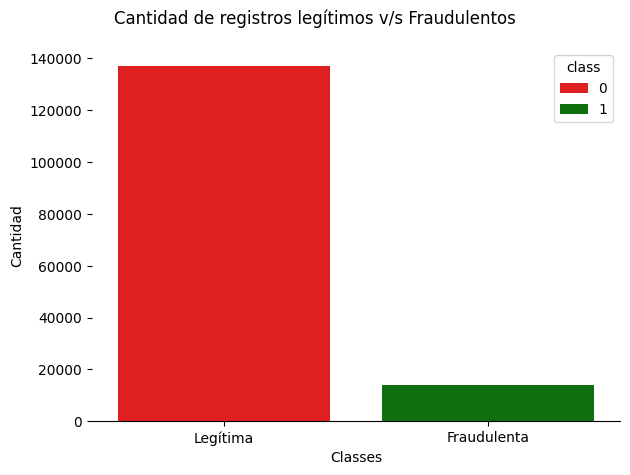

In [16]:
g = sns.countplot(data=numeric_df, x='class', hue='class', palette={0:'r', 1:'g'})
plt.suptitle('Cantidad de registros legítimos v/s Fraudulentos')
plt.xlabel('Classes')
plt.ylabel('Cantidad')
sns.axes_style('ticks')
g.set_xticklabels(["Legítima", "Fraudulenta"])
sns.despine(left=True)
plt.tight_layout()
plt.show()


### 📢 Detalle

El dataframe tiene un desbalance alto entre la clase 0 y 1. La primera es totalmente prevalente con un 90.6 % de los datos mientras que la segúnda solo representa 9.4 % de los datos.

-   Aplicar oversampling de la clase minoritaria parece una estrategia indispensable en los datos.

### **2.1.2 Purchase_value**

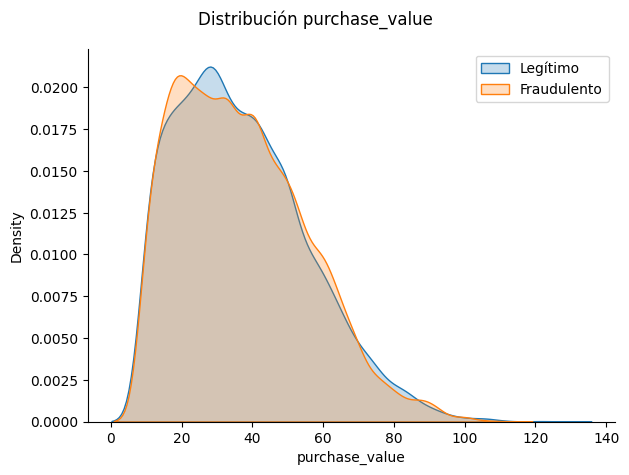

In [17]:

sns.kdeplot(data=numeric_df[numeric_df['class']==0].sample(min(10000, len(numeric_df[numeric_df['class']==0]))), x='purchase_value', fill=True) # Muestra para no congelar
sns.kdeplot(data=numeric_df[numeric_df['class']==1], x='purchase_value', fill=True) # Distribución clase 1 con purchase_value
plt.legend(['Legítimo', 'Fraudulento'])
plt.suptitle('Distribución purchase_value')
sns.despine()
plt.tight_layout()
plt.show()

In [18]:
pd.concat([
    numeric_df[numeric_df['class']==0]['purchase_value'].describe(),
    numeric_df[numeric_df['class']==1]['purchase_value'].describe()
], axis=1, keys=['class = 0', 'class = 1']).T


,count,mean,std,min,25%,50%,75%,max
class = 0,136961.00,36.93,18.32,9.00,22.00,35.00,49.00,154.00
class = 1,14151.00,36.99,18.40,9.00,22.00,35.00,49.00,111.00


### 💾 **Observaciones**

Lo primero que salta a la luz es que ambas distribuciones son identicas o casi identicas compartiendo el mismo skewness a la derecha.

Tanto la clase 0 como la clase 1 tienen casi los mismos datos en las métricas centrales.
- El promedio, el std, el min los rangos cuartilicos son casi identicos.


La similitud tan grande en las distribuciones me lleva a pensar que los movimientos fraudulentos siguen la distribución de los datos legales para no levantar sospechas. Serán las distribuciones iguales ?

In [19]:
valores_legitimos = numeric_df[numeric_df['class']==0]['purchase_value']
valores_fraudulentos = numeric_df[numeric_df['class']==1]['purchase_value']

Considerando los gráficos las distribuciones se ven lejos de ser normal pero aplicaremos igualmente un test estadístico para conocer la normalidad o no. Debido al tamaño de muestra utilizamos D'Agostino-Pearson

In [20]:
stat1, p1 = stats.normaltest(valores_fraudulentos)
stat2, p2 = stats.normaltest(valores_legitimos)
print(f"Fraude:    p={p1:.4f}")
print(f"No fraude: p={p2:.4f}")


Fraude:    p=0.0000
No fraude: p=0.0000


# Observación

Datos no normales por lo que necesitamos un test no paramétricos apra saber si las distribuciones son iguales o no.

In [21]:
stat, p = stats.mannwhitneyu(valores_fraudulentos, valores_legitimos)
print(f"stat={stat:.4f}, p={p:.4f}")

stat=970851302.5000, p=0.7180



Por lo tanto el monto no influye si es fraude o no.

In [22]:
from scipy import stats

stat, p = stats.ks_2samp(valores_fraudulentos, valores_legitimos)
print(f"stat={stat:.4f}, p={p:.4f}")

stat=0.0116, p=0.0646


Falla en rechazar la hipotesis nula de que las distribuciones son identicas. Por lo que lo más probable es que si lo sean como se ve arriba

# CONCLUSIÓN

Según lo observado tanto en los gráficos como en los diferentes tests estadisticos. El `purchase_value` no tiene evidencia estadisticamente relevante para ser un discriminante fuerte en si existira fraude o no.

### **2.1.3 Age**

In [23]:
pd.concat([
    numeric_df[numeric_df['class']==0]['age'].describe(),
    numeric_df[numeric_df['class']==1]['age'].describe()
], axis=1, keys=['class = 0', 'class = 1']).T


,count,mean,std,min,25%,50%,75%,max
class = 0,136961.00,33.12,8.62,18.00,27.00,33.00,39.00,76.00
class = 1,14151.00,33.32,8.57,18.00,27.00,33.00,39.00,68.00


En age para ambas clases igualmente el promedio, std y los rangos intercuartilicos son casi identicos.

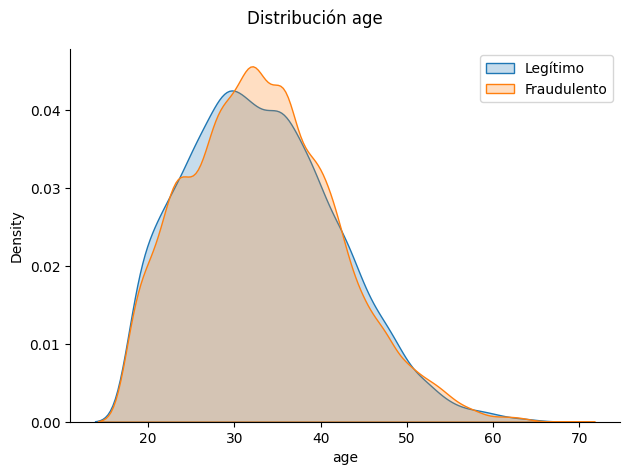

In [24]:
sns.kdeplot(data=numeric_df[numeric_df['class']==0].sample(min(10000, len(numeric_df[numeric_df['class']==0]))), x='age', fill=True) # Muestra para no congelar
sns.kdeplot(data=numeric_df[numeric_df['class']==1], x='age', fill=True) # Distribución clase 1 con age
plt.legend(['Legítimo', 'Fraudulento'])
plt.suptitle('Distribución age')
sns.despine()
plt.tight_layout()
plt.show()

In [25]:
from scipy import stats

age_fraude    = df[df['class'] == 1]['age'].values
age_no_fraude = df[df['class'] == 0]['age'].values

stat_mw, p_mw = stats.mannwhitneyu(age_fraude, age_no_fraude)
stat_ks, p_ks = stats.ks_2samp(age_fraude, age_no_fraude)

print(f"Mann-Whitney: stat={stat_mw:.4f}, p={p_mw:.4f}")
print(f"KS test:      stat={stat_ks:.4f}, p={p_ks:.4f}")

Mann-Whitney: stat=983476583.5000, p=0.0035
KS test:      stat=0.0198, p=0.0001


In [26]:
print(f"Age media fraude:    {age_fraude.mean():.2f}")
print(f"Age media no fraude: {age_no_fraude.mean():.2f}")
print(f"Diferencia:          {abs(age_fraude.mean() - age_no_fraude.mean()):.2f} años")

Age media fraude:    33.32
Age media no fraude: 33.12
Diferencia:          0.20 años


Lo primero que salta a la vista que la distribución observada entre transaccciones fraudulentas y lefitimas parecen idénticas. Por otro lado los test estadisticos rechazan sus hipotesis nula, sugiriendo diferencias estadisticamente significantes entre estas clases.
Esta aparente contradicción viene dada en parte por el gran tamaño muestral, que detectan diferencias mínimas que en realidad no tienen relevancia. Por lo tanto considerando las metricas centrales se puede observar que `age` no posee una significancia práctica como feature dominante para detectar fraudes.

## **2.2. Variables Str**

In [27]:
df_str = df_merged.select_dtypes(include=['object', 'str'])
df_str.columns

Index(['signup_time', 'purchase_time', 'device_id', 'source', 'browser', 'sex',
       'country'],
      dtype='str')

In [28]:
df_merged.groupby('class')['sex'].size()

class
0    136961
1     14151
Name: sex, dtype: int64

C:\Users\remoto\AppData\Local\Temp\ipykernel_23568\61939778.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(data=df_merged, x='sex', col='class',kind='count', palette='pastel')


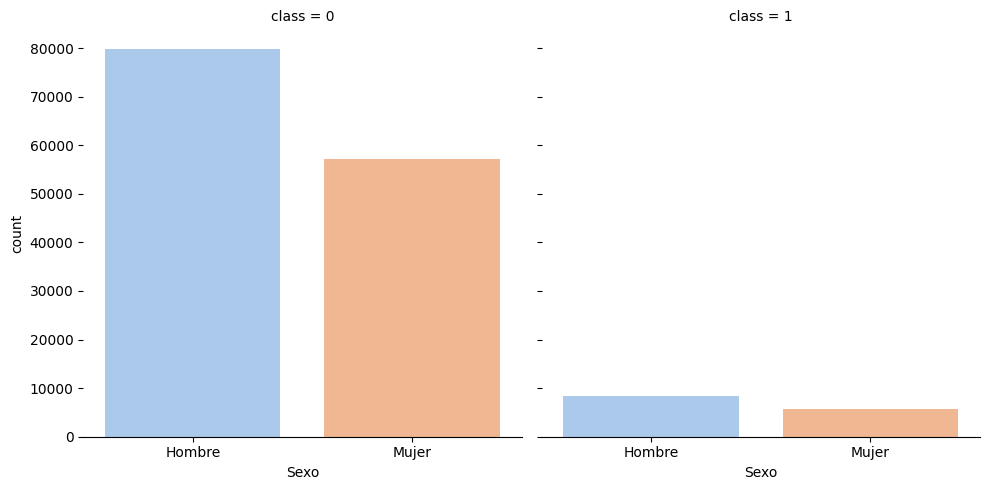

In [29]:
g = sns.catplot(data=df_merged, x='sex', col='class',kind='count', palette='pastel')
g.set_xticklabels(['Hombre', 'Mujer'])
sns.despine(left=True)
g.set_axis_labels('Sexo')
plt.show()


🔔 **Detalle**

Es clara la diferencia en la cuenta entre ambos segmentos que obviamente viene dada por la proporcion desmezurada de los registros legítimos. En ambos casos son los hombres los que están presente en más registros. En general no se ve una diferencia para los movimientos legítimos y fraudulentos. Necesitamos conocer la cuenta por cada sexo y cada clase

In [30]:
cuenta_sex = pd.crosstab(df_merged['sex'], df_merged['class'])
cuenta_sex

class,0,1
sex,,
F,57102,5717
M,79859,8434


🔔 **Detalle**

Como se menciona anteriormente la diferencia de cuentas es grande y se puede observar que al parecer son bastante proporcionales en cuanto a cantidad de hombres y mujeres en cada clase. Para confirmar necesitamos conocer los porcentajes.

In [31]:
cuenta_sex_norm = cuenta_sex.div(cuenta_sex.sum(1), axis=0)
cuenta_sex_norm

C:\Users\remoto\AppData\Local\Temp\ipykernel_23568\3192470434.py:1: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  cuenta_sex_norm = cuenta_sex.div(cuenta_sex.sum(1), axis=0)


class,0,1
sex,,
F,0.91,0.09
M,0.90,0.10


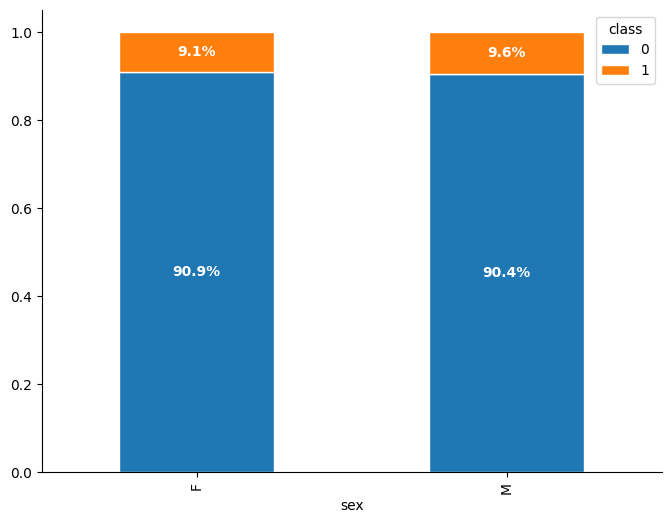

In [32]:
ax = cuenta_sex_norm.plot(kind='bar', 
                  stacked=True, 
                  figsize=(8, 6),
                  edgecolor='white')
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    if height > 0: # Solo poner texto si hay valor
        ax.text(x + width/2, 
                y + height/2, 
                f'{height:.1%}', 
                horizontalalignment='center', 
                verticalalignment='center',
                color='white',
                fontweight='bold')

sns.despine()
plt.show()

🔔 **Detalle**

Ahora con los porcentajes es claro ver que no hay una diferencia real entre legítimo y/o fraudulento. Esto nos indica que probablemente no es una feature que nos ayude en gran medida a predecir nuestro target


In [33]:
from scipy.stats import chi2_contingency

# 1. Usamos el crosstab que ya conoces (SIN normalizar, con los conteos reales)
tab_contingencia = pd.crosstab(df_merged['sex'], df_merged['class'])

# 2. Ejecutamos el test
chi2, p, dof, expected = chi2_contingency(tab_contingencia)

print(f"Estadístico Chi2: {chi2:.4f}")
print(f"P-valor: {p:.4e}")

Estadístico Chi2: 8.7638
P-valor: 3.0727e-03


In [34]:
import numpy as np

n = tab_contingencia.sum().sum()
min_dim = min(tab_contingencia.shape) - 1
v_cramer = np.sqrt(chi2 / (n * min_dim))

print(f"V de Cramer: {v_cramer:.4f}")

V de Cramer: 0.0076


### 🧠  **Conclusiones**

Según lo revisado es claro conocer que la feature sex no tiene un poder predictivo grande para una predicción. Lo siguiente se basa en lo siguiente:
- **Proporciones similares:** Las relaciones entre ambas clases es casi la misma.
- **El efecto del N grande:** Chi2 nos indica que no son independientes pero este resultado se encuentra enmascarado por nuestro n de muestra tan alto. Aplicando v de cramer podemos conocer si esta relación es significativa o en realidad está enmascarada por el tamaño de muestra. Considerando el valor obtenido nos queda claro que la dependencia observada por chi2 en realidad estaba influenciada por el numero de muestra y en realidad las variables son tan poco dependiente que en realidad son dependientes.

Por lo tanto la variable `sex` no nos sirve como una variable predictiva fuerte

C:\Users\remoto\AppData\Local\Temp\ipykernel_23568\889503142.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(data=df_merged, x='source', col='class',kind='count', palette='pastel')


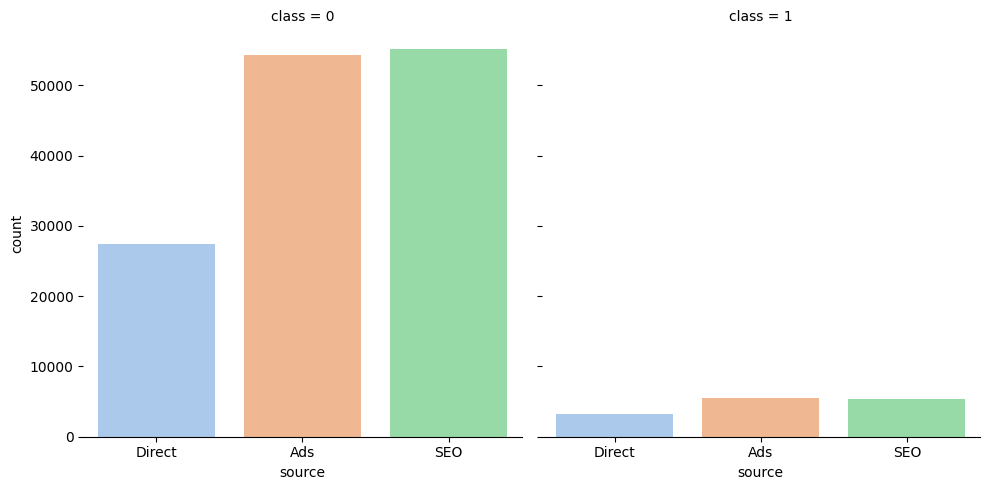

In [35]:
g = sns.catplot(data=df_merged, x='source', col='class',kind='count', palette='pastel')
sns.despine(left=True)
plt.show()


In [36]:
cuenta_source = pd.crosstab(df_merged['source'], df_merged['class'])
cuenta_source

class,0,1
source,,
Ads,54368,5513
Direct,27390,3226
SEO,55203,5412


In [37]:
ptc_source = cuenta_source.div(cuenta_source.sum(1), axis=0)
ptc_source

C:\Users\remoto\AppData\Local\Temp\ipykernel_23568\3469075074.py:1: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  ptc_source = cuenta_source.div(cuenta_source.sum(1), axis=0)


class,0,1
source,,
Ads,0.91,0.09
Direct,0.89,0.11
SEO,0.91,0.09


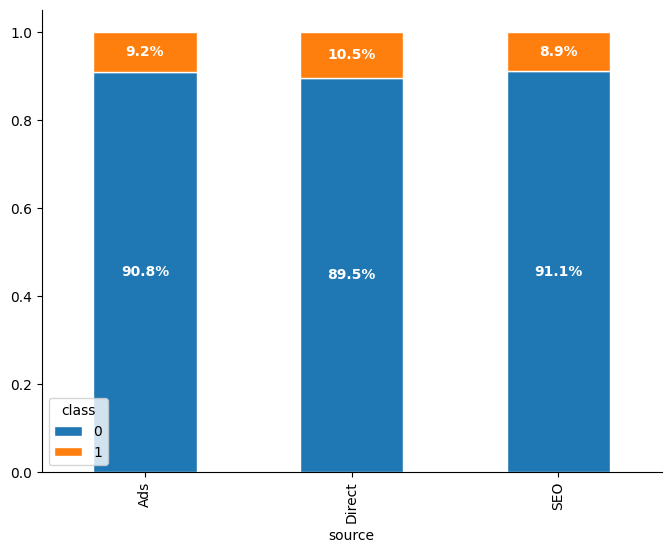

In [38]:
ax = ptc_source.plot(kind='bar', 
                  stacked=True, 
                  figsize=(8, 6),
                  edgecolor='white')
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    if height > 0: # Solo poner texto si hay valor
        ax.text(x + width/2, 
                y + height/2, 
                f'{height:.1%}', 
                horizontalalignment='center', 
                verticalalignment='center',
                color='white',
                fontweight='bold')

sns.despine()
plt.show()

In [39]:
from scipy.stats import chi2_contingency



chi2, p, dof, expected = chi2_contingency(cuenta_source)

print(f"Estadístico Chi2: {chi2:.4f}")
print(f"P-valor: {p:.4e}")

Estadístico Chi2: 64.9232
P-valor: 7.9820e-15


In [40]:
n = cuenta_source.sum().sum()
min_dim = min(cuenta_source.shape) - 1 
v_cramer_source = np.sqrt(chi2 / (n * min_dim))

print(f"V de Cramer (Source): {v_cramer_source:.4f}")

V de Cramer (Source): 0.0207


### 🧠  **Conclusiones**

- La significancia estadística es muy pequeña (7.98 x 10^-15) con un chi2 de 64.92. Lo que viene a evidenciar que las diferencias entre canales no son casualidad.
- El salto de 2% en la columna fraude de Direct puede estar causando este efecto en chi2.
- Considerando la v de cramer de 0.0207 sigue indicando que esta significancia estadistica esta distorsionada por el tamaño de n y que es debil pero es el triple de fuerte que la del sexo.


Si bien `source` tampoco es un predictor fuerte para nuestro target, tiene mejor poder predictivo que `sex`

C:\Users\remoto\AppData\Local\Temp\ipykernel_23568\83092607.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(data=df_merged, x='browser', col='class',kind='count', palette='pastel')


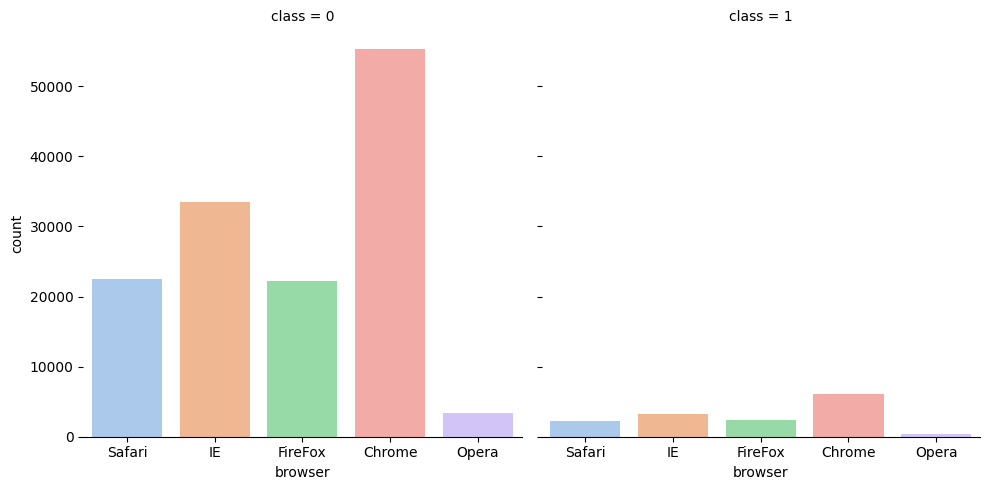

In [41]:
g = sns.catplot(data=df_merged, x='browser', col='class',kind='count', palette='pastel')
sns.despine(left=True)
plt.show()


In [42]:
cuenta_browser = pd.crosstab(df_merged['browser'], df_merged['class'])
cuenta_browser

class,0,1
browser,,
Chrome,55363,6069
FireFox,22268,2342
IE,33540,3187
Opera,3348,328
Safari,22442,2225


In [43]:
ptc_browser = cuenta_browser.div(cuenta_browser.sum(1), axis=0)
ptc_browser

C:\Users\remoto\AppData\Local\Temp\ipykernel_23568\1697596803.py:1: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  ptc_browser = cuenta_browser.div(cuenta_browser.sum(1), axis=0)


class,0,1
browser,,
Chrome,0.90,0.10
FireFox,0.90,0.10
IE,0.91,0.09
Opera,0.91,0.09
Safari,0.91,0.09


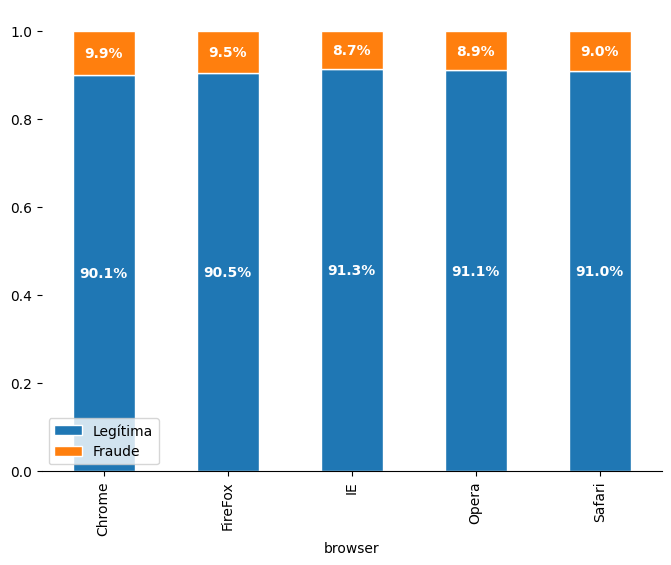

In [44]:

ax = ptc_browser.plot(kind='bar', stacked=True, figsize=(8,6), edgecolor='white')

for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    if height > 0: # Solo poner texto si hay valor
        ax.text(x + width/2, 
                y + height/2, 
                f'{height:.1%}', 
                horizontalalignment='center', 
                verticalalignment='center',
                color='white',
                fontweight='bold')
sns.despine(left=True)
plt.legend(['Legítima','Fraude'])
plt.show()


In [45]:
from scipy.stats import chi2_contingency



chi2, p, dof, expected = chi2_contingency(cuenta_browser)

print(f"Estadístico Chi2: {chi2:.4f}")
print(f"P-valor: {p:.4e}")

Estadístico Chi2: 44.5566
P-valor: 4.9160e-09


In [46]:
n = cuenta_source.sum().sum()
min_dim = min(cuenta_source.shape) - 1 
v_cramer_source = np.sqrt(chi2 / (n * min_dim))

print(f"V de Cramer (Source): {v_cramer_source:.4f}")

V de Cramer (Source): 0.0172


### 🧠  **Conclusiones**

- Muy parecido a las variables anteriores y debido al desbalance importante de los datos en el primer grafico se aprecia que la escala es muy diferente pero se puede ver una relación muy similar entre ambas clases.
- En las crosstab se puede apreciar de mejor forma que en general se sigue la misma proporcion de los datos dominando con un 90% los datos legítimos frente aproximadamente a un 10 % los fraudes.
- Cada `browser` sigue una proporción similar tanto en fraude como en un movimiento legítimo.
- La prueba de `chi2` rechaza la hipotesis nula de independencia con un valor de `p_value` bastante bajo indicando que existe mayor probabilidad de una relación dependiente. Aún asi debido a nuestro alto `n` esto puede ser un resultado sesgado. Según la `v de cramer` podemos decir que esta relación es baja y que lo más probable que las variables sean independientes.
- Con todo esto y lo demás podemos decir que `browser` por si sola no es una buena feature para predecir si hay fraude o no.

In [47]:
df_merged.loc[df_merged['country'].isna()].head(10)

,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class,lower_bound_ip_address,upper_bound_ip_address,country
0,62421,2015-02-16 00:17:05,2015-03-08 10:00:39,46,ZCLZTAJPCRAQX,Direct,Safari,M,36,52093.50,0,NaN,NaN,NaN
1,173212,2015-03-08 04:03:22,2015-03-20 17:23:45,33,YFGYOALADBHLT,Ads,IE,F,30,93447.14,0,NaN,NaN,NaN
2,242286,2015-05-17 16:45:54,2015-05-26 08:54:34,33,QZNVQTUITFTHH,Direct,FireFox,F,32,105818.50,0,NaN,NaN,NaN
3,370003,2015-03-03 19:58:39,2015-05-28 21:09:13,33,PIBUQMBIELMMG,Ads,IE,M,40,117566.66,0,NaN,NaN,NaN
4,119824,2015-03-20 00:31:27,2015-04-05 07:31:46,55,WFIIFCPIOGMHT,Ads,Safari,M,38,131423.79,0,NaN,NaN,NaN
5,266190,2015-06-18 00:38:29,2015-06-27 04:35:25,21,NSJYRZTYTCMFV,SEO,Chrome,M,32,155130.40,0,NaN,NaN,NaN
6,241175,2015-07-17 11:31:56,2015-08-14 22:21:41,87,QXEAKJVUIOMJT,SEO,Chrome,M,33,155399.11,0,NaN,NaN,NaN
7,138971,2015-07-11 05:31:15,2015-08-04 04:43:58,21,AMZQWDRAWLNCE,SEO,Chrome,M,24,159119.79,0,NaN,NaN,NaN
8,377916,2015-02-21 02:25:55,2015-03-21 09:09:10,60,HTQECMMGBKUSC,Ads,IE,M,37,166326.78,0,NaN,NaN,NaN
9,21325,2015-05-12 02:33:40,2015-05-20 20:15:35,35,FYNYUCGEWCKGR,Ads,IE,M,25,207999.64,0,NaN,NaN,NaN


In [48]:
df_merged.loc[df_merged['country'].isna(), 'country'] = 'Unknown'

In [49]:
df_merged.loc[df_merged['country'].isna()]

,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class,lower_bound_ip_address,upper_bound_ip_address,country


In [50]:
grupo = df_merged.groupby(['class', 'country'])[['user_id']].agg(total=('user_id','count'))
grupo_ordenado = grupo.sort_values(by=['class', 'total'], ascending=[True, False])
top_10_por_clase = grupo_ordenado.groupby(level=0).head(10).reset_index()



C:\Users\remoto\AppData\Local\Temp\ipykernel_23568\2339377671.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


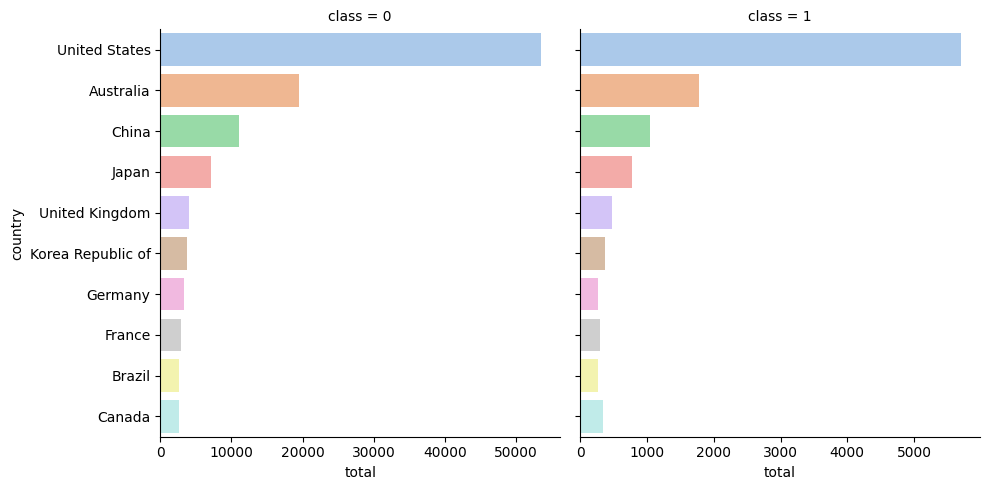

In [51]:
g = sns.catplot(
    data=top_10_por_clase,
    x='total',
    y='country',
    col='class',
    kind='bar',
    palette='pastel',
    sharex=False
)

   

In [52]:
pct_country_2 = pd.crosstab(df_merged['country'], df_merged['class'], normalize='index').round(3) * 100
pct_country_2 = pct_country_2.rename(columns={0: 'no_fraude_%', 1: 'fraude_%'})
pct_country_2['total_obs'] = df_merged['country'].value_counts()
pct_country_2.sort_values(by='total_obs', ascending=False)

class,no_fraude_%,fraude_%,total_obs
country,,,
United States,90.40,9.60,59222
Australia,91.60,8.40,21228
China,91.30,8.70,12038
Japan,90.30,9.70,7918
United Kingdom,89.40,10.60,4492
...,...,...,...
South Sudan,100.00,0.00,1
Tajikistan,100.00,0.00,1
Turkmenistan,0.00,100.00,1


In [53]:
unknown_countries = grupo.loc[pd.IndexSlice[:, 'Unknown'], :]

In [54]:
unknown_countries

,,total
class,country,
0,Unknown,572
1,Unknown,62


In [55]:
pct_country = pd.crosstab(df_merged['country'], df_merged['class'], normalize='index').round(3) * 100
pct_country = pct_country.rename(columns={0: 'no_fraude_%', 1: 'fraude_%'})
pct_country['total_obs'] = df_merged['country'].value_counts()
pct_country = pct_country.sort_values('fraude_%', ascending=False).head(20)

In [56]:
pct_country

class,no_fraude_%,fraude_%,total_obs
country,,,
Turkmenistan,0.00,100.00,1
Namibia,56.50,43.50,23
Sri Lanka,58.10,41.90,31
Luxembourg,61.10,38.90,72
Virgin Islands (U.S.),66.70,33.30,3
Ecuador,73.60,26.40,106
Tunisia,73.70,26.30,118
Peru,73.90,26.10,119
Bolivia,75.50,24.50,53


C:\Users\remoto\AppData\Local\Temp\ipykernel_23568\168949970.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


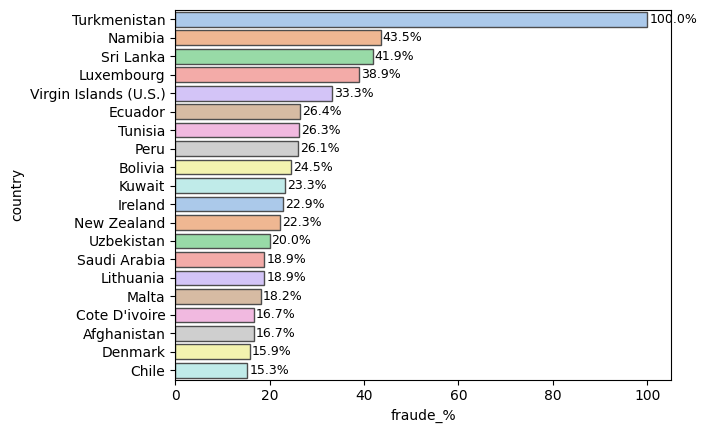

In [57]:

ax = sns.barplot(
    data=pct_country,
    x='fraude_%',
    y=pct_country.index,
    palette='pastel',
    edgecolor='0.3'
)

# Añadir etiquetas con porcentaje
for p in ax.patches:
    width = p.get_width()
    ax.annotate(
        f'{width:.1f}%',
        (width + 0.4, p.get_y() + p.get_height()/2),
        va='center',
        fontsize=9,
        color='black'
    )

In [58]:
import pandas as pd
from scipy.stats import chi2_contingency

# Tabla de contingencia observada
tabla = pd.crosstab(df_merged['country'], df_merged['class'])  # o df_merged['fraude']

print(tabla)

class                    0   1
country                       
Afghanistan              5   1
Albania                 13   0
Algeria                109  13
Angola                  23   1
Antigua and Barbuda      3   0
...                    ...  ..
Viet Nam               513  37
Virgin Islands (U.S.)    2   1
Yemen                    1   0
Zambia                  10   0
Zimbabwe                 6   0

[182 rows x 2 columns]


In [59]:
chi2, p, dof, expected = chi2_contingency(tabla)

print(f"Estadístico chi-cuadrado: {chi2:.2f}")
print(f"Grados de libertad: {dof}")
print(f"p-valor: {p:.6f}")


Estadístico chi-cuadrado: 877.81
Grados de libertad: 181
p-valor: 0.000000


In [60]:

n_total = tabla.sum().sum()          
k = min(tabla.shape)              

cramers_v = np.sqrt(chi2 / (n_total * (k - 1)))

print(f"\nTamaño total de la muestra (n): {n_total:,}")
print(f"Cramér's V: {cramers_v:.4f}")



Tamaño total de la muestra (n): 151,112
Cramér's V: 0.0762


### 🧠  **Conclusiones**

- Lo primero relevante es que hay 634 datos en los que el país no existe devido a que en el `merge_asoft` no estaba en ningun rango.
- A cada uno de estos valores se le inputo Unknown por simplicidad.
- Existen un total de 182 países de los cuales tanto en fraude como en legítimo USA es el que más valores tienen.
- Si bien en el primer gráfico de barras se repite la misma frecuencia de países que son los que más fraudes tienen en la tabla de abajo podemos ver el porcentaje de fraude en cada uno de estos y para el top 10 se puede ver que es un porcentaje que ronda al 10 % la cantidad de fraudes.
- Los países con mayor porcentaje de fraude en cambio en general son paises que no tiene tanta frecuencia en el dataset.
- Chi2 dice que hay una relacion significativa de dependencia pero v de cramer dice que es debil esta relación. 


Según lo anterior podemos ver que si bien no es fuerte predictor si podemos encontrar una relación con aquellos paises que el % de fraude es alto y quizas generar una columna que capte esta relación.


## **2.3 VARIABLES TEMPORALES**

In [61]:
df_merged['signup_time'] = pd.to_datetime(df_merged['signup_time'], format='%Y-%m-%d %H:%M:%S')
df_merged['purchase_time'] = pd.to_datetime(df_merged['purchase_time'], format='%Y-%m-%d %H:%M:%S')

In [62]:
# signup_time

df_merged['signup_time'] = pd.to_datetime(df_merged['signup_time'], format='%Y-%m-%d %H:%M:%S')
df_merged['signup_time_month'] = df_merged['signup_time'].dt.month
df_merged['signup_time_day_name'] = df_merged['signup_time'].dt.day_name()
df_merged['signup_time_weekday'] = df_merged['signup_time'].dt.weekday
df_merged['signup_time_hour_and_minute'] = df_merged['signup_time'].dt.strftime('%H:%M:%S')

# purchase_time
df_merged['purchase_time'] = pd.to_datetime(df_merged['purchase_time'], format='%Y-%m-%d %H:%M:%S')
df_merged['purchase_time_month'] = df_merged['purchase_time'].dt.month
df_merged['purchase_time_day_name'] = df_merged['purchase_time'].dt.day_name()
df_merged['purchase_time_hour'] = df_merged['purchase_time'].dt.hour
df_merged['purchase_time_weekday'] = df_merged['purchase_time'].dt.weekday



In [171]:
max_year = df_merged['purchase_time'].max()
min_year = df_merged['purchase_time'].min()

print(f'El año máximo de compra es: {max_year}')
print(f'El año mínimo de compra es: {min_year}')
print(f'Rango de años: {min_year} - {max_year}')

El año máximo de compra es: 2015-12-16 02:56:05
El año mínimo de compra es: 2015-01-01 00:00:44
Rango de años: 2015-01-01 00:00:44 - 2015-12-16 02:56:05


In [172]:
max_year = df_merged['signup_time'].max()
min_year = df_merged['signup_time'].min()

print(f'El año máximo de compra es: {max_year}')
print(f'El año mínimo de compra es: {min_year}')
print(f'Rango de años: {min_year} - {max_year}')

El año máximo de compra es: 2015-08-18 04:40:29
El año mínimo de compra es: 2015-01-01 00:00:42
Rango de años: 2015-01-01 00:00:42 - 2015-08-18 04:40:29


### 🧠  **Conclusiones**

- Solo tenemos datos del año 2015
- Hay compras desde Enero hasta mediados de diciembre
- El ultimo registro fue en Agosto.

### **2.3.1 Purchase_time_month**

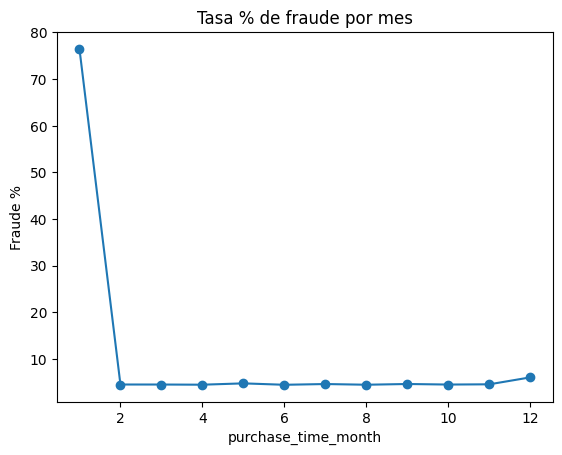

In [63]:
monthly_fraud_rate = df_merged.groupby('purchase_time_month')['class'].mean() * 100
monthly_fraud_rate.plot(kind='line', marker='o', title='Tasa % de fraude por mes', ylabel='Fraude %')
plt.show()

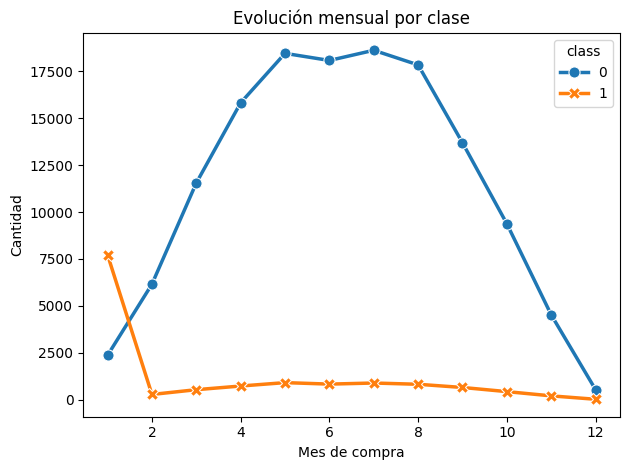

In [64]:
agrupado = df_merged.groupby(['purchase_time_month','class']).size().to_frame('total')
# Convertir el MultiIndex a columnas normales
agrupado_reset = agrupado.reset_index()

sns.lineplot(
    data=agrupado_reset,
    x='purchase_time_month',
    y='total',
    hue='class',
    style='class',          
    markers=True,           
    dashes=False,
    linewidth=2.5,
    markersize=8,
)

plt.title('Evolución mensual por clase')
plt.xlabel('Mes de compra')
plt.ylabel('Cantidad')
plt.tight_layout()
plt.show()

In [65]:
ratio_mensual = df_merged.groupby('purchase_time_month')['class'].mean()
z_scores = (ratio_mensual - ratio_mensual.mean()) / ratio_mensual.std()
print("Meses con anomalías altas en fraude:")
print(z_scores[z_scores > 2].sort_values(ascending=False))

Meses con anomalías altas en fraude:
purchase_time_month
1   3.17
Name: class, dtype: float64


In [66]:
volumen_mes = df_merged['purchase_time_month'].value_counts().sort_index()
prop_volumen_mes = (
    df_merged['purchase_time_month']
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
)
prop_volumen_mes

purchase_time_month
1     6.68
2     4.27
3     8.00
4    10.95
5    12.81
6    12.51
7    12.91
8    12.35
9     9.49
10    6.50
11    3.14
12    0.38
Name: proportion, dtype: float64

In [67]:
fraudes_mes_rate = pd.crosstab(df_merged['class'], df_merged['purchase_time_month'], normalize='columns').mul(100)
ratio_total_mes = df_merged['class'].mean() * 100


In [68]:
conteos = pd.crosstab(df_merged['class'], df_merged['purchase_time_month'])


volumen_mes = df_merged['purchase_time_month'].value_counts().sort_index()

prop_volumen_mes = (
    df_merged['purchase_time_month']
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
)

fraud_rate_global = df_merged['class'].mean() * 100

resumen_mes = pd.DataFrame({
    'total_transacciones': volumen_mes,
    'prop_volumen_%': prop_volumen_mes,
    'fraudes': conteos.loc[1],
    'no_fraudes': conteos.loc[0],
    'fraud_rate_%': fraudes_mes_rate.loc[1]
})

resumen_mes['fraud_rate_global_%'] = fraud_rate_global
resumen_mes['lift'] = resumen_mes['fraud_rate_%'] / fraud_rate_global

resumen_mes

,total_transacciones,prop_volumen_%,fraudes,no_fraudes,fraud_rate_%,fraud_rate_global_%,lift
purchase_time_month,,,,,,,
1,10097,6.68,7723,2374,76.49,9.36,8.17
2,6449,4.27,291,6158,4.51,9.36,0.48
3,12090,8.00,545,11545,4.51,9.36,0.48
4,16551,10.95,740,15811,4.47,9.36,0.48
5,19364,12.81,921,18443,4.76,9.36,0.51
6,18908,12.51,842,18066,4.45,9.36,0.48
7,19507,12.91,900,18607,4.61,9.36,0.49
8,18662,12.35,833,17829,4.46,9.36,0.48
9,14347,9.49,663,13684,4.62,9.36,0.49


### 🧠  **Conclusiones**

- Lo primero y más notorio es la diferencia abismal entre el primer mes de compras en relación con los demás meses. El primer mes tiene > 76 % de fraudes mientras en los meses restante oscila entre el 6 a 4 %. Esta diferencia es demasiado grande y por lo tanto mirar el dataset a mayor porfundidad y tratar de entender que pasa en este mes es importante.

- Según el z-score podemos confirmar que el primer mes de los datos es el mes donde se concentra la mayor cantidad de fraudes.
- El primer mes si bien no son los meses de más compras tampoco es uno de los menores. La mayor cantidad de compras se centra entre mayo y agosto.
- El `lift` (ratio fraude x mes / el ratio global o mean) para el primer mes confirma que el primer mes es anomalamente el mes con mayor porcentaje de fraudes.


La feature es interesante puesto que muestra que casi todo el fraude del dataset se encuentra en el primer mes. Esto es interesante puesto que esta diferencia tan grande en relación a los otros meses es demasiado alta. Encontrar que está pasando con esta y otras variables para responder que pasa es importante puesto que una diferencia tan grande tambien podria estar ligada a errores en el dataset si no se pueden respaldar de una forma coherente


### **2.3.2 signup_time_month**

In [69]:
signup_month = pd.crosstab(df_merged['signup_time_month'], df_merged['class'])
signup_month

class,0,1
signup_time_month,,
1,18484,8494
2,16717,818
3,18676,879
4,18023,872
5,18494,844
6,17774,859
7,18557,897
8,10236,488


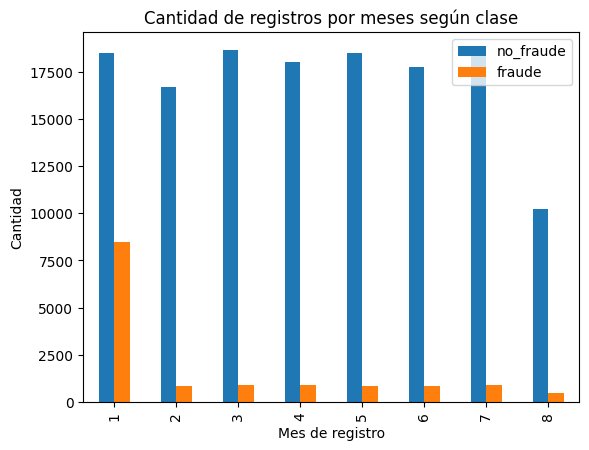

In [70]:
signup_month.plot(
    kind='bar',
    title='Cantidad de registros por meses según clase',
    ylabel = 'Cantidad',
    xlabel= 'Mes de registro'
    )
plt.legend(['no_fraude', 'fraude'])
plt.show()

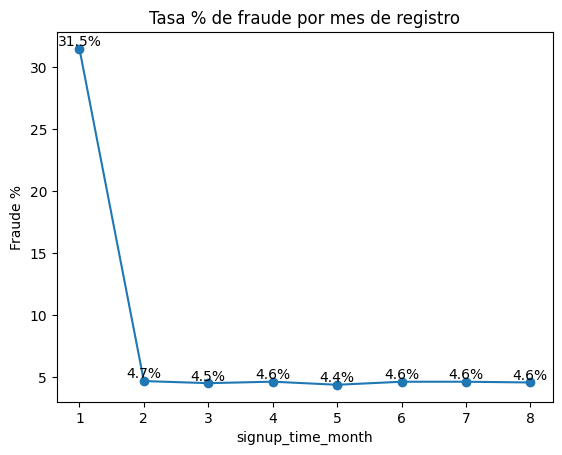

In [71]:
ratio_registros_mes = df_merged.groupby('signup_time_month')['class'].mean() * 100


fig,ax = plt.subplots()


ratio_registros_mes.plot(
    kind='line',
    marker='o',
    title='Tasa % de fraude por mes de registro',
    ylabel='Fraude %',
    ax=ax
)

# agregar etiquetas
for x, y in zip(ratio_registros_mes.index, ratio_registros_mes.values):
    ax.text(x, y, f'{y:.1f}%', ha='center', va='bottom')

plt.show()


### 🧠  **Conclusiones**

- La cantidad de registros para el primer mes de registro al igual que el primer mes de compra es altísimo (31 %) en comparación a los demás meses (~ 4.6 %).
- Esto sumado a lo visto que las compras del primer son altisimo entrega una evidencia importante que los fraudes estan hechos en su gran mayoría el primer mes entre que se registra y se compra.

Con esto necesitamos encontrar la relación `purchase_time` - `signup_time`.



### **2.3.3 diferencia_signup_purchase_dias : Feature Eng**

In [72]:

df_merged['diferencia_signup_purchase_dias'] = (
    (df_merged['purchase_time'] - df_merged['signup_time']) / np.timedelta64(1, 'D')
)


In [73]:
bins = [
    0,
    1 / 86400,     # < 1 segundo
    3 / 86400,     # 1–3 seg
    10 / 86400,    # 3–10 seg
    60 / 86400,    # 10 seg – 1 min
    300 / 86400,   # 1–5 min
    3600 / 86400,  # 5 min – 1 h
    1,             # 1 h – 1 día
    7,             # 1–7 días
    float('inf')   # > 7 días
]

labels = [
    "< 1 seg",
    "1–3 seg",
    "3–10 seg",
    "10 seg – 1 min",
    "1–5 min",
    "5 min – 1 h",
    "1 h – 1 día",
    "1–7 días",
    "> 7 días"
]

df_merged['tiempo_categoria'] = pd.cut(
    df_merged['diferencia_signup_purchase_dias'],
    bins=bins,
    labels=labels,
    right=False
)

In [74]:
df_merged['tiempo_categoria'].value_counts()

tiempo_categoria
> 7 días          135272
1–3 seg             7600
1–7 días            7082
1 h – 1 día         1117
5 min – 1 h           39
1–5 min                2
< 1 seg                0
3–10 seg               0
10 seg – 1 min         0
Name: count, dtype: int64

In [75]:
timpocat_ctab = pd.crosstab(df_merged['tiempo_categoria'],
            df_merged['class'])

In [76]:
df_plot = timpocat_ctab.reset_index()

df_plot = df_plot.melt(id_vars='tiempo_categoria', var_name='class', value_name='conteo')


C:\Users\remoto\AppData\Local\Temp\ipykernel_23568\3699344729.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(


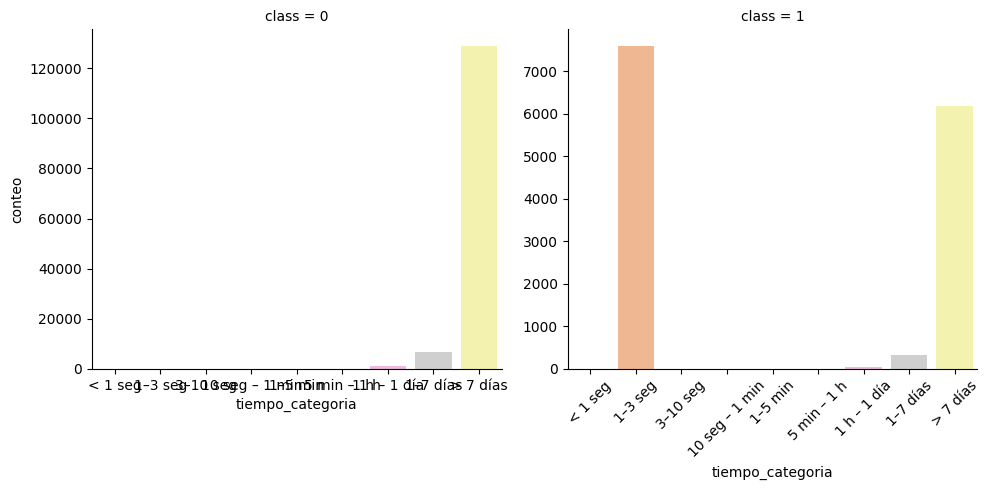

In [77]:

sns.catplot(
    data=df_plot,
    x='tiempo_categoria',
    y='conteo',
    col='class',
    kind='bar',
    sharey=False,
    palette='pastel'
)

plt.xticks(rotation=45) # Rota las etiquetas si son muy largas
plt.tight_layout()
plt.show()

In [78]:
df_merged['tiempo_cat_reducido'] = (
    df_merged['tiempo_categoria']
    .astype(str)
    .replace({
        "< 1 seg": "ultra_fast",
        "1–3 seg": "ultra_fast",
        "3–10 seg": "ultra_fast",
        "10 seg – 1 min": "ultra_fast",
        "1–5 min": "fast",
        "5 min – 1 h": "fast",
        "1 h – 1 día": "medium",
        "1–7 días": "slow",
        "> 7 días": "slow"
    })
)
tabla = pd.crosstab(df_merged['tiempo_cat_reducido'], df_merged['class'])
chi2, p, dof, expected = chi2_contingency(tabla)


print("Chi2:", chi2)
print("p-value:", p)

cramers_v = np.sqrt(chi2 / (n * (k - 1)))

print("Cramér's V:", cramers_v)

Chi2: 77454.08279537059
p-value: 0.0
Cramér's V: 0.715933494216688


### 🧠  **OBSERVACIONES**

- La mayor parte de las compras fraudulentas se centran a los 1 y 3 segundos después de realizado el registro.
- La otra mayor cantidad se encuentra en > 7 días pero esto representa todos los datos que vimos anteriormente donde en todos los meses oscila entre un 4 y un 5.6 %.
- Chi2 rechaza la hipotesis nula por lo que lo más probable que exista una relación de dependencia entre la variable cat y el fraude lo que se ve ratificado por la v de cramer que en nuestro caso es alta.

La velocidad entre registro y compra es tan rapida que lo más probable es que sea un sistema automatizado puesto que humanamente es dificil ser tan consistente en tantos datos. La v de cramer tan alta nos dice que sino es un sistema automatizado deberiamos dudar de los datos.







In [79]:
df_merged[df_merged['tiempo_cat_reducido'] == 'ultra_fast'].head()

,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,...,signup_time_day_name,signup_time_weekday,signup_time_hour_and_minute,purchase_time_month,purchase_time_day_name,purchase_time_hour,purchase_time_weekday,diferencia_signup_purchase_dias,tiempo_categoria,tiempo_cat_reducido
68,125058,2015-01-07 20:53:50,2015-01-07 20:53:51,26,FBHIRVGVKKWAI,Ads,IE,F,36,2278095.82,...,Wednesday,2,20:53:50,1,Wednesday,20,2,0.00,1–3 seg,ultra_fast
69,287232,2015-01-07 20:53:41,2015-01-07 20:53:42,26,FBHIRVGVKKWAI,Ads,IE,F,36,2278095.82,...,Wednesday,2,20:53:41,1,Wednesday,20,2,0.00,1–3 seg,ultra_fast
70,300104,2015-01-07 20:53:49,2015-01-07 20:53:50,26,FBHIRVGVKKWAI,Ads,IE,F,36,2278095.82,...,Wednesday,2,20:53:49,1,Wednesday,20,2,0.00,1–3 seg,ultra_fast
71,363461,2015-01-07 20:53:47,2015-01-07 20:53:48,26,FBHIRVGVKKWAI,Ads,IE,F,36,2278095.82,...,Wednesday,2,20:53:47,1,Wednesday,20,2,0.00,1–3 seg,ultra_fast
72,52675,2015-01-07 20:53:42,2015-01-07 20:53:43,26,FBHIRVGVKKWAI,Ads,IE,F,36,2278095.82,...,Wednesday,2,20:53:42,1,Wednesday,20,2,0.00,1–3 seg,ultra_fast


### 🧠  **OBSERVACIONES**

- Lo primero que se observa es una repeticion en la ip, device_id, source,browser para distintos user_ids.

Esta relación puede estar dando pistas de porque estas compras son tan rápidas.

In [80]:
df_merged[df_merged['tiempo_cat_reducido'] == 'ultra_fast']['device_id'].value_counts()

device_id
KIPFSCNUGOLDP    19
ZUSVMDEZRBDTX    19
NGQCKIADMZORL    19
ITUMJCKWEYNDD    19
CQTUVBYIWWWBC    18
                 ..
QEAFUMJNWECHM     3
EKWTABTNBCHTE     3
FAALRIFEEVUYX     2
JFJVNEQHZQHVL     2
RPYTMFHWBZUFD     1
Name: count, Length: 760, dtype: int64

In [81]:
serie_device_count = df_merged[df_merged['tiempo_cat_reducido'] == 'ultra_fast']['device_id'].value_counts()
print(f'Combinaciones unicas de device: {serie_device_count[serie_device_count==1].shape[0]}')
print(f'Combinaciones donde device aparece más de 4 veces: {serie_device_count[serie_device_count>=4].shape[0]}')

Combinaciones unicas de device: 1
Combinaciones donde device aparece más de 4 veces: 753


In [82]:
serie_device_count = df_merged[df_merged['tiempo_cat_reducido'] != 'ultra_fast']['device_id'].value_counts()
print(f'Combinaciones unicas de device: {serie_device_count[serie_device_count==1].shape[0]}')
print(f'Combinaciones donde device aparece más de 4 veces: {serie_device_count[serie_device_count>=4].shape[0]}')

Combinaciones unicas de device: 132491
Combinaciones donde device aparece más de 4 veces: 1


### 🧠  **OBSERVACIONES**

- Algo interesante a primera vista es que hay varios device_id que tiene mas de una ocurrencia.
- Otra cosa es que solo hay 1 ocurrencia en donde no se repite el mismo `device`
- La mayoria de los datos repiten `device` a lo menos 4 veces.
- En datos donde el `tiempo_cat_reducido` es diferente a `ultra_fast` donde ocurre la mayor parte del fraude podemos ver que la gran parte de los usuarios tiene solo una combinacion unica de `device_id`

In [83]:
valores_asociados_fraude = df_merged[df_merged['tiempo_cat_reducido'] == 'ultra_fast'].groupby(
    ['device_id','source', 'browser', 'ip_address']).size().sort_values(ascending=False)

valores_asociados_fraude

device_id      source  browser  ip_address   
KIPFSCNUGOLDP  SEO     Safari   576060872.53     19
ZUSVMDEZRBDTX  Ads     Safari   1502818419.73    19
NGQCKIADMZORL  SEO     FireFox  2050963888.16    19
ITUMJCKWEYNDD  Ads     Safari   3874757617.26    19
CQTUVBYIWWWBC  SEO     IE       348493400.69     18
                                                 ..
OXWYEJXFZILGS  Direct  Safari   1181834297.18     3
EKWTABTNBCHTE  SEO     Chrome   3520413039.03     3
JFJVNEQHZQHVL  Ads     FireFox  2295521363.63     2
FAALRIFEEVUYX  Direct  Chrome   1786159256.86     2
RPYTMFHWBZUFD  Ads     Chrome   3804140211.67     1
Length: 760, dtype: int64

In [84]:
valores_normales = df_merged[df_merged['tiempo_cat_reducido'] != 'ultra_fast'].groupby(
    ['device_id','source', 'browser', 'ip_address']).size().sort_values(ascending=False)

valores_normales

device_id      source  browser  ip_address   
AAALBGNHHVMKG  Direct  Chrome   2494581089.27    1
AAAWIHVCQELTP  Ads     Chrome   809263681.30     1
AAAXJHWCLISKY  Ads     IE       2891496.87       1
AAAXXOZJRZRAO  Ads     FireFox  1377849233.09    1
AABFGRPBQHWFQ  Ads     Opera    3960443103.61    1
                                                ..
ZZZGSIJRNCXBJ  Ads     Safari   2553895471.15    1
ZZZIKLJSVSQMF  Ads     IE       3265673643.94    1
ZZZKJIZHJEDFN  Direct  Safari   2415066584.10    1
ZZZMVOGBAJVTM  Ads     Chrome   3404179483.84    1
ZZZXASJUVUNMV  Direct  Chrome   4035153773.47    1
Length: 143512, dtype: int64

In [85]:
valores_asociados_fraude[valores_asociados_fraude==1].values

array([1])

In [86]:
valores_asociados_fraude[valores_asociados_fraude>1].values.sum()

np.int64(7599)

In [87]:
valores_normales[valores_normales==1].values.sum()

np.int64(143512)

In [88]:
valores_normales[valores_normales>1].values.sum()

np.int64(0)

### 🧠  **OBSERVACIONES**

- En datos donde la compra fue muy rápida y hubo fraude se puede ver que la combinación `device_id`, `source`, `browser` e `ip_adress` se repitió más de una vez en diferentes usuario casi el 99 % de las veces, mientras que fue única solo 1 vez.
- En datos más normales donde ya no existe estas compras tan rápidas se observa que en todos los casos esta combinación fue unica para cada cliente.

Por lo tanto en todas estas compras fraudulentas tenemos que la repetición de estas en diferente usuario es una flag grande junto con la velocidad entre registro y compra.

In [123]:
# número de transacciones por ip
df_merged['ip_count'] = df_merged.groupby('ip_address')['user_id'].transform('count')

# número de transacciones por device
df_merged['device_count'] = df_merged.groupby('device_id')['user_id'].transform('count')

# número de cuentas por ip
df_merged['users_per_ip'] = df_merged.groupby('ip_address')['user_id'].transform('nunique')



C:\Users\remoto\AppData\Local\Temp\ipykernel_23568\3211838080.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  g =sns.catplot(


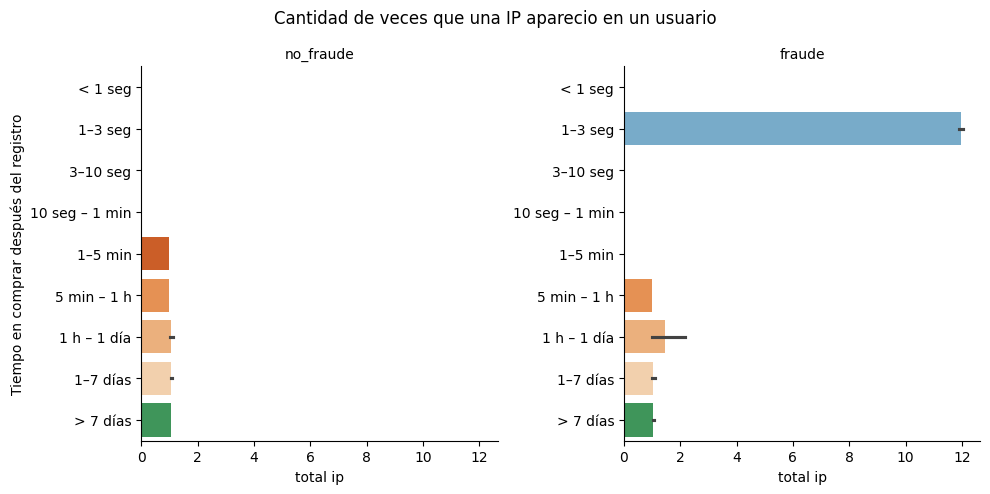

In [90]:
df_merged['class_label'] = df_merged['class'].map({0: "no_fraude", 1: "fraude"})

g =sns.catplot(
    data=df_merged,
    x =df_merged['ip_count'],
    y =df_merged['tiempo_categoria'],
    kind ='bar',
    col='class_label',
    sharey=False,
    palette='tab20c'
)
plt.suptitle('Cantidad de veces que una IP aparecio en un usuario')
g.tight_layout()
g.set_axis_labels(y_var='Tiempo en comprar después del registro', x_var='total ip')
g.set_titles(col_template="{col_name}")
plt.show()

C:\Users\remoto\AppData\Local\Temp\ipykernel_23568\1988498311.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  g =sns.catplot(


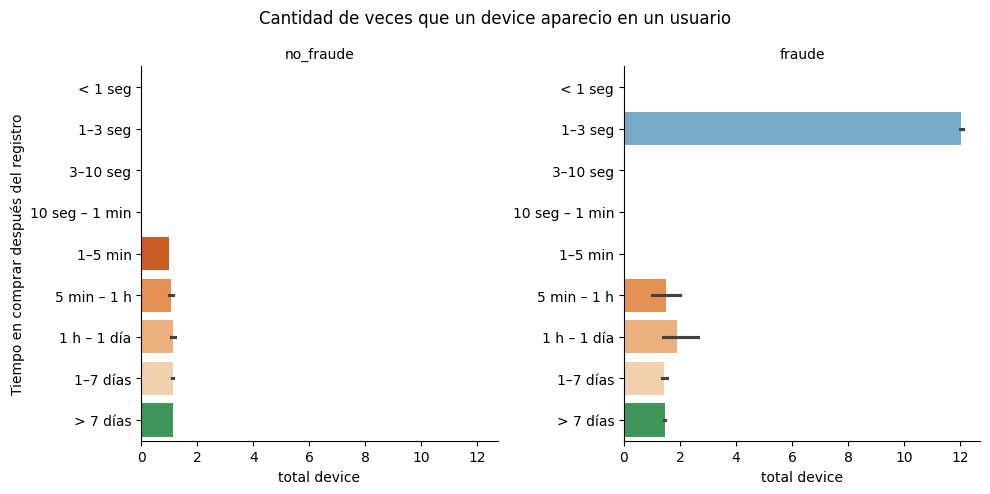

In [91]:

g =sns.catplot(
    data=df_merged,
    x =df_merged['device_count'],
    y =df_merged['tiempo_categoria'],
    kind ='bar',
    col='class_label',
    sharey=False,
    palette='tab20c'
)
plt.suptitle('Cantidad de veces que un device aparecio en un usuario')
g.tight_layout()
g.set_axis_labels(y_var='Tiempo en comprar después del registro', x_var='total device')
g.set_titles(col_template="{col_name}")
plt.show()

C:\Users\remoto\AppData\Local\Temp\ipykernel_23568\2713801143.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  g =sns.catplot(


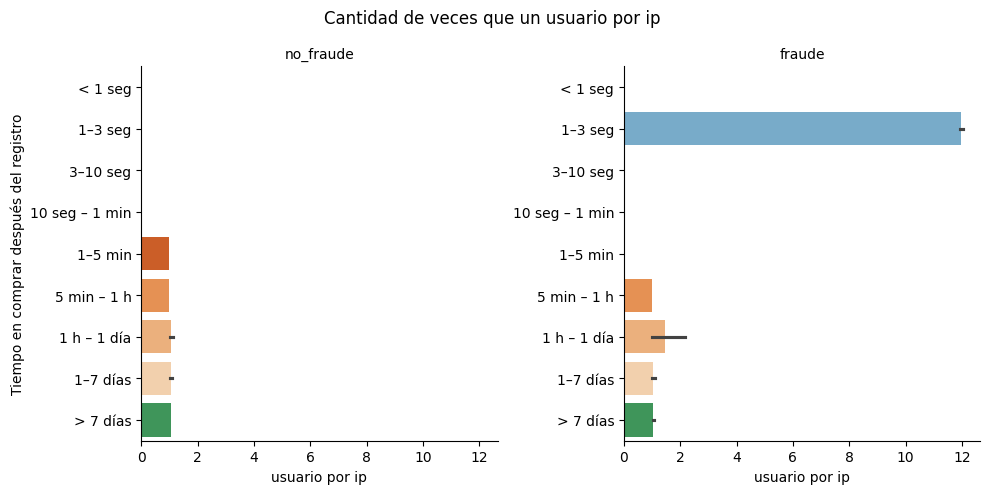

In [93]:
df_merged['class_label'] = df_merged['class'].map({0: "no_fraude", 1: "fraude"})

g =sns.catplot(
    data=df_merged,
    x =df_merged['users_per_ip'],
    y =df_merged['tiempo_categoria'],
    kind ='bar',
    col='class_label',
    sharey=False,
    palette='tab20c'
)
plt.suptitle('Cantidad de veces que un usuario por ip ')
g.tight_layout()
g.set_axis_labels(y_var='Tiempo en comprar después del registro', x_var='usuario por ip')
g.set_titles(col_template="{col_name}")
plt.show()

### 🧠  **OBSERVACIONES**

- Confirmamos con estos grágicos que para el primer mes entre los 1 a 3 segundos después del registro tanto `ip` y `device` son extremandamente altos.
- Tambien re afirmamos que para todo los demás datos del dataset en general se da un unico `device` e ip

C:\Users\remoto\AppData\Local\Temp\ipykernel_23568\906663948.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  g =sns.catplot(


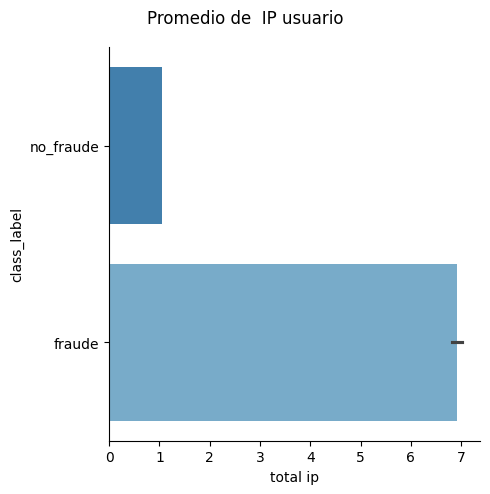

In [107]:

g =sns.catplot(
    data=df_merged,
    x =df_merged['ip_count'],
    y ='class_label',
    kind ='bar',
    sharey=False,
    palette='tab20c'
)
plt.suptitle('Promedio de  IP usuario')
g.tight_layout()
g.set_axis_labels(x_var='total ip')
g.set_titles(col_template="{col_name}")
plt.show()

C:\Users\remoto\AppData\Local\Temp\ipykernel_23568\3033348957.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  g =sns.catplot(


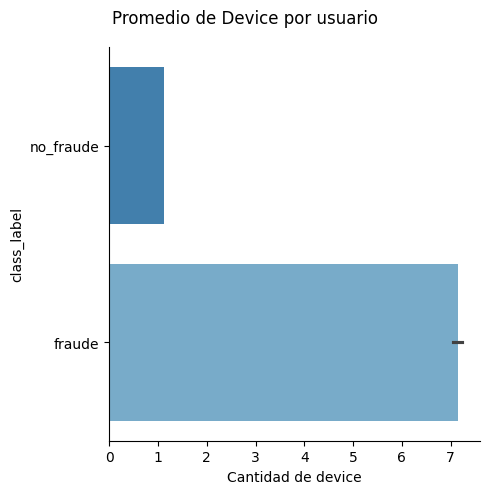

In [106]:

g =sns.catplot(
    data=df_merged,
    x =df_merged['device_count'],
    y ='class_label',
    kind ='bar',
    sharey=False,
    palette='tab20c'
)
plt.suptitle('Promedio de Device por usuario')
g.tight_layout()
g.set_axis_labels( x_var='Cantidad de device')
g.set_titles(col_template="{col_name}")
plt.show()

### 🧠  **OBSERVACIONES**

- Tanto `ip` como `device` tienen promedios bastante altos lo que principalmente está influenciado por el primer mes como vimos anteriormente. Esta diferencia entre fraude y no_fraude los convierte en buenos predictores para la variable objetivo